Name: Prerna Kale

Roll number: 24102B2001

Class: BE CMPN B

R PROGRAMMING LAB 2

In [1]:
required <- c("naniar", "skimr")
missing_pkgs <- required[!sapply(required, requireNamespace, quietly = TRUE)]
if (length(missing_pkgs) > 0) {
  install.packages(missing_pkgs, repos = "https://cloud.r-project.org")
}

library(naniar)
library(skimr)

set.seed(42)
options(stringsAsFactors = FALSE)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




In [2]:
heart_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
heart_file <- "processed.cleveland.data"

if (!file.exists(heart_file)) {
  download.file(heart_url, heart_file, mode = "wb")
}

heart_names <- c(
  "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
  "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
)

heart <- read.csv(
  heart_file,
  header = FALSE,
  col.names = heart_names,
  na.strings = "?"
)

str(heart)
head(heart)


'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ num     : int  0 2 1 0 0 0 3 0 2 1 ...


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


In [3]:
heart_lab3 <- heart

# Add deliberate invalid/missing/extreme values.
heart_lab3$trestbps[c(1, 2, 3)] <- c(-120, NA, 320)
heart_lab3$trestbps[c(4, 5)] <- c(-80, 350)

cat("Injected problematic trestbps values:\n")
print(heart_lab3$trestbps[1:10])


Injected problematic trestbps values:
 [1] -120   NA  320  -80  350  120  140  120  130  140


In [4]:
clean_bp_value <- function(bp) {
  if (is.na(bp)) {
    return(NA_real_)
  } else if (bp < 0) {
    return(NA_real_)
  } else if (bp > 250) {
    return(250)
  } else {
    return(bp)
  }
}

# Demonstration
test_values <- c(-20, NA, 120, 260, 350)
sapply(test_values, clean_bp_value)


[1]  NA  NA 120 250 250

In [5]:
heart_lab3$trestbps_clean <- Vectorize(clean_bp_value)(heart_lab3$trestbps)

head(
  heart_lab3[, c("trestbps", "trestbps_clean")],
  10
)


,trestbps,trestbps_clean
,<dbl>,<dbl>
1,-120,NA
2,NA,NA
3,320,250
4,-80,NA
5,350,250
6,120,120
7,140,140
8,120,120
9,130,130


In [6]:
safe_mean_bp <- function(x) {
  tryCatch(
    {
      if (!is.numeric(x)) stop("BP input must be numeric.")
      if (all(is.na(x))) stop("Cannot calculate mean: all BP values are missing.")

      result <- mean(x, na.rm = TRUE)
      message("Mean BP calculated successfully.")
      result
    },
    warning = function(w) {
      message("Warning while calculating mean BP: ", conditionMessage(w))
      NA_real_
    },
    error = function(e) {
      message("BP mean error handled safely: ", conditionMessage(e))
      NA_real_
    }
  )
}

safe_ratio <- function(chol, bp) {
  tryCatch(
    {
      if (!is.numeric(chol) || !is.numeric(bp)) {
        stop("Both cholesterol and BP must be numeric.")
      }
      if (is.na(bp) || bp <= 0) {
        stop("Invalid denominator: BP must be a positive, non-missing value.")
      }
      if (is.na(chol)) {
        stop("Invalid numerator: cholesterol is missing.")
      }

      chol / bp
    },
    warning = function(w) {
      message("Ratio warning handled safely: ", conditionMessage(w))
      NA_real_
    },
    error = function(e) {
      message("Ratio error handled safely: ", conditionMessage(e))
      NA_real_
    }
  )
}

mean_bp <- safe_mean_bp(heart_lab3$trestbps_clean)
mean_bp

cat("\nRatio examples:\n")
print(safe_ratio(200, 120))
print(safe_ratio(200, 0))
print(safe_ratio(200, NA))


Mean BP calculated successfully.



[1] 132.39


Ratio examples:
[1] 1.666667


Ratio error handled safely: Invalid denominator: BP must be a positive, non-missing value.



[1] NA


Ratio error handled safely: Both cholesterol and BP must be numeric.



[1] NA


In [7]:
clean_bp_loop <- function(x) {
  result <- x

  for (i in seq_along(result)) {
    if (is.na(result[i])) {
      next
    } else if (result[i] < 0) {
      result[i] <- NA_real_
    } else if (result[i] > 250) {
      result[i] <- 250
    }
  }

  result
}

system.time({
  bp_loop <- clean_bp_loop(heart_lab3$trestbps)
})


   user  system elapsed 
  0.007   0.000   0.007 

In [8]:
clean_bp_vectorized <- function(x) {
  result <- x
  result[!is.na(result) & result < 0] <- NA_real_
  result[!is.na(result) & result > 250] <- 250
  result
}

system.time({
  bp_vectorized <- clean_bp_vectorized(heart_lab3$trestbps)
})


   user  system elapsed 
      0       0       0 

In [9]:
benchmark_iterations <- 1000

loop_time <- system.time({
  for (j in seq_len(benchmark_iterations)) {
    invisible(clean_bp_loop(heart_lab3$trestbps))
  }
})

vector_time <- system.time({
  for (j in seq_len(benchmark_iterations)) {
    invisible(clean_bp_vectorized(heart_lab3$trestbps))
  }
})

benchmark_results <- data.frame(
  Approach = c("For loop", "Vectorized"),
  User_Time_Seconds = c(loop_time["user.self"], vector_time["user.self"]),
  System_Time_Seconds = c(loop_time["sys.self"], vector_time["sys.self"]),
  Elapsed_Time_Seconds = c(loop_time["elapsed"], vector_time["elapsed"])
)

print(benchmark_results)


    Approach User_Time_Seconds System_Time_Seconds Elapsed_Time_Seconds
1   For loop             0.071               0.000                0.072
2 Vectorized             0.016               0.004                0.020


In [10]:
heart_lab3$trestbps <- bp_vectorized

lab3_validation <- data.frame(
  Missing_BP = sum(is.na(heart_lab3$trestbps)),
  Minimum_BP = min(heart_lab3$trestbps, na.rm = TRUE),
  Maximum_BP = max(heart_lab3$trestbps, na.rm = TRUE),
  Mean_BP = mean(heart_lab3$trestbps, na.rm = TRUE),
  Median_BP = median(heart_lab3$trestbps, na.rm = TRUE),
  Negative_Remaining = sum(heart_lab3$trestbps < 0, na.rm = TRUE),
  Above_250_Remaining = sum(heart_lab3$trestbps > 250, na.rm = TRUE)
)

print(lab3_validation)

stopifnot(
  lab3_validation$Negative_Remaining == 0,
  lab3_validation$Above_250_Remaining == 0
)
cat("\nValidation passed: no negative or >250 BP values remain.\n")


  Missing_BP Minimum_BP Maximum_BP Mean_BP Median_BP Negative_Remaining
1          3         94        250  132.39       130                  0
  Above_250_Remaining
1                   0

Validation passed: no negative or >250 BP values remain.


In [11]:
write.csv(
  heart_lab3,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

cat("Created: cleaned_heart_data.csv\n")


Created: cleaned_heart_data.csv


In [12]:
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
adult_file <- "adult.data"

if (!file.exists(adult_file)) {
  download.file(adult_url, adult_file, mode = "wb")
}

adult_names <- c(
  "age", "workclass", "fnlwgt", "education", "education_num",
  "marital_status", "occupation", "relationship", "race", "sex",
  "capital_gain", "capital_loss", "hours_per_week", "native_country",
  "income"
)

adult <- read.csv(
  adult_file,
  header = FALSE,
  col.names = adult_names,
  na.strings = "?",
  strip.white = TRUE
)

str(adult)
head(adult)


'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  "State-gov" "Self-emp-not-inc" "Private" "Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  "Bachelors" "Bachelors" "HS-grad" "11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  "Never-married" "Married-civ-spouse" "Divorced" "Married-civ-spouse" ...
 $ occupation    : chr  "Adm-clerical" "Exec-managerial" "Handlers-cleaners" "Handlers-cleaners" ...
 $ relationship  : chr  "Not-in-family" "Husband" "Not-in-family" "Husband" ...
 $ race          : chr  "White" "White" "White" "Black" ...
 $ sex           : chr  "Male" "Male" "Male" "Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ native_country: chr  "United-States" "Uni

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [13]:
adult_lab4 <- adult

# Numeric NA
adult_lab4$age[c(1, 2)] <- NA

# Blank categorical strings
adult_lab4$workclass[c(3, 4)] <- ""

# NaN in a numeric column
adult_lab4$education_num[c(5, 6)] <- NaN

# Impossible age values
adult_lab4$age[c(7, 8)] <- 999

# NULL demonstration: absence of an object
null_demo <- NULL

cat("is.null(null_demo):", is.null(null_demo), "\n")
cat("A NULL object is different from a data-frame cell containing NA/blank/NaN.\n")


is.null(null_demo): TRUE 
A NULL object is different from a data-frame cell containing NA/blank/NaN.


In [14]:
cat("NA count in age:", sum(is.na(adult_lab4$age)), "\n")
cat("NaN count in education_num:", sum(is.nan(adult_lab4$education_num)), "\n")
cat("NULL demonstration:", is.null(null_demo), "\n")
cat("Blank workclass values:", sum(adult_lab4$workclass == "", na.rm = TRUE), "\n")
cat("Impossible age = 999:", sum(adult_lab4$age == 999, na.rm = TRUE), "\n")

missing_summary_before <- data.frame(
  Variable = names(adult_lab4),
  Missing_Count = sapply(adult_lab4, function(x) sum(is.na(x))),
  Missing_Percentage = sapply(adult_lab4, function(x) mean(is.na(x)) * 100)
)

print(missing_summary_before)


NA count in age: 2 
NaN count in education_num: 2 
NULL demonstration: TRUE 
Blank workclass values: 2 
Impossible age = 999: 2 
                     Variable Missing_Count Missing_Percentage
age                       age             2        0.006142317
workclass           workclass          1836        5.638647462
fnlwgt                 fnlwgt             0        0.000000000
education           education             0        0.000000000
education_num   education_num             2        0.006142317
marital_status marital_status             0        0.000000000
occupation         occupation          1843        5.660145573
relationship     relationship             0        0.000000000
race                     race             0        0.000000000
sex                       sex             0        0.000000000
capital_gain     capital_gain             0        0.000000000
capital_loss     capital_loss             0        0.000000000
hours_per_week hours_per_week             0        0

In [15]:
miss_var_summary(adult_lab4)


variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
age,2,0.006[4m1[24m[4m4[24m
education_num,2,0.006[4m1[24m[4m4[24m
fnlwgt,0,0
education,0,0
marital_status,0,0
relationship,0,0


In [16]:
median_impute <- function(x) {
  if (!is.numeric(x)) {
    stop("median_impute() requires a numeric vector.")
  }

  valid_values <- x[!is.na(x) & !is.nan(x)]

  if (length(valid_values) == 0) {
    stop("No valid observations available to calculate a median.")
  }

  med <- median(valid_values)
  x[is.na(x) | is.nan(x)] <- med
  x
}

# Demonstration
demo_numeric <- c(20, 22, NA, 25, NaN, 30)
median_impute(demo_numeric)


[1] 20.0 22.0 23.5 25.0 23.5 30.0

In [17]:
# Impossible ages become NA
adult_lab4$age[adult_lab4$age == 999] <- NA

# Blank categorical values become "Unknown"
adult_lab4$workclass[adult_lab4$workclass == ""] <- "Unknown"

# Convert NaN to missing before imputation
adult_lab4$education_num[is.nan(adult_lab4$education_num)] <- NA

# Median-impute selected numeric variables
numeric_columns <- c(
  "age", "fnlwgt", "education_num",
  "capital_gain", "capital_loss", "hours_per_week"
)

for (col in numeric_columns) {
  adult_lab4[[col]] <- median_impute(adult_lab4[[col]])
}

# Replace any remaining blank categorical values
categorical_columns <- c(
  "workclass", "education", "marital_status", "occupation",
  "relationship", "race", "sex", "native_country", "income"
)

for (col in categorical_columns) {
  adult_lab4[[col]][is.na(adult_lab4[[col]]) | adult_lab4[[col]] == ""] <- "Unknown"
}

complete_before <- sum(complete.cases(adult_lab4))
incomplete_before <- nrow(adult_lab4) - complete_before

cat("Complete rows after treatment:", complete_before, "\n")
cat("Incomplete rows after treatment:", incomplete_before, "\n")


Complete rows after treatment: 32561 
Incomplete rows after treatment: 0 


In [18]:
missing_summary_after <- data.frame(
  Variable = names(adult_lab4),
  Missing_Count = sapply(adult_lab4, function(x) sum(is.na(x))),
  Missing_Percentage = sapply(adult_lab4, function(x) mean(is.na(x)) * 100)
)

comparison <- merge(
  missing_summary_before,
  missing_summary_after,
  by = "Variable",
  suffixes = c("_Before", "_After")
)

comparison$Reduction <- comparison$Missing_Count_Before - comparison$Missing_Count_After

print(comparison)

cat("\nOverall missing values before:", sum(missing_summary_before$Missing_Count), "\n")
cat("Overall missing values after:", sum(missing_summary_after$Missing_Count), "\n")


         Variable Missing_Count_Before Missing_Percentage_Before
1             age                    2               0.006142317
2    capital_gain                    0               0.000000000
3    capital_loss                    0               0.000000000
4       education                    0               0.000000000
5   education_num                    2               0.006142317
6          fnlwgt                    0               0.000000000
7  hours_per_week                    0               0.000000000
8          income                    0               0.000000000
9  marital_status                    0               0.000000000
10 native_country                  583               1.790485550
11     occupation                 1843               5.660145573
12           race                    0               0.000000000
13   relationship                    0               0.000000000
14            sex                    0               0.000000000
15      workclass        

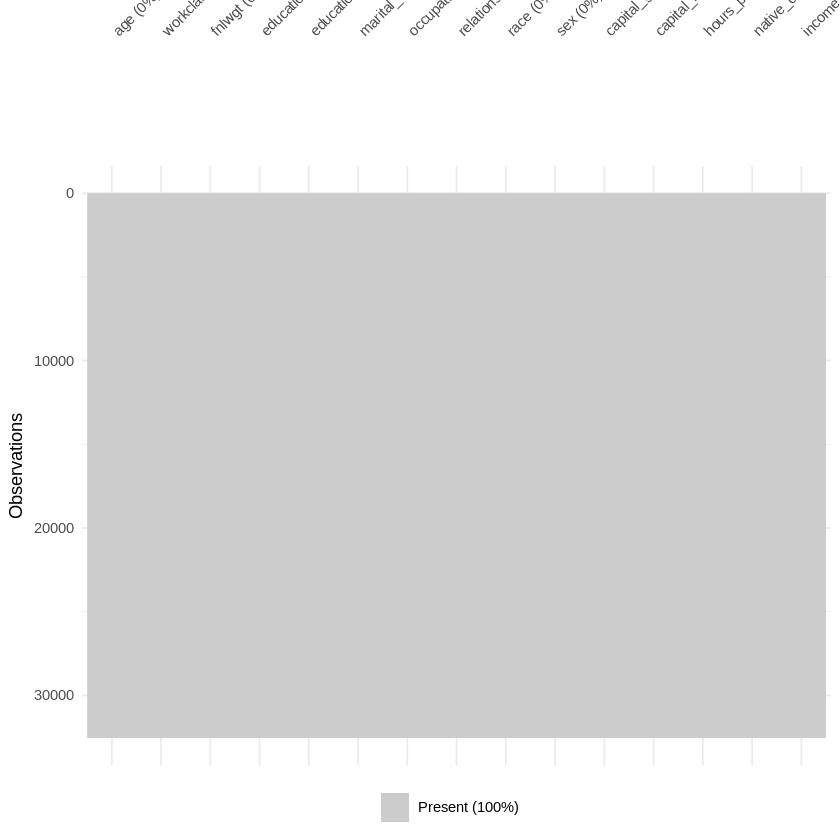

In [19]:
vis_miss(adult_lab4)


In [20]:
skim(adult_lab4)


,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,7,16,0,9,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,5,17,0,15,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,0,1,4,26,0,42,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [21]:
validation_lab4 <- list(
  impossible_age_999 = sum(adult_lab4$age == 999, na.rm = TRUE),
  selected_numeric_missing = sapply(
    adult_lab4[numeric_columns],
    function(x) sum(is.na(x) | is.nan(x))
  ),
  blank_categorical_values = sapply(
    adult_lab4[categorical_columns],
    function(x) sum(x == "", na.rm = TRUE)
  )
)

print(validation_lab4)

stopifnot(
  validation_lab4$impossible_age_999 == 0,
  all(validation_lab4$selected_numeric_missing == 0),
  all(validation_lab4$blank_categorical_values == 0)
)

cat("\nLab 4 validation passed.\n")


$impossible_age_999
[1] 0

$selected_numeric_missing
           age         fnlwgt  education_num   capital_gain   capital_loss 
             0              0              0              0              0 
hours_per_week 
             0 

$blank_categorical_values
     workclass      education marital_status     occupation   relationship 
             0              0              0              0              0 
          race            sex native_country         income 
             0              0              0              0 


Lab 4 validation passed.


In [22]:
write.csv(
  adult_lab4,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat("Created: cleaned_adult_data.csv\n")


Created: cleaned_adult_data.csv
